In [58]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

from numba import cuda

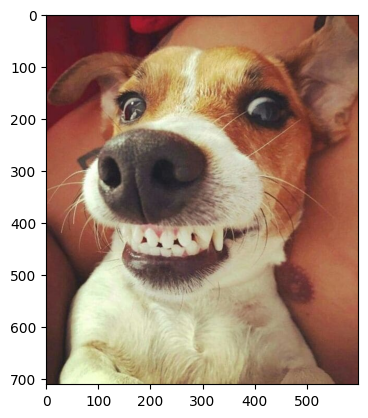

In [59]:
img = plt.imread("/content/dog.jpg")

plt.imshow(img)

grayscale image binarization



In [60]:
THRESHOLD = 128
height, width, channels = img.shape

In [99]:
devSrc = cuda.to_device(img)
devGray = cuda.device_array((height, width), dtype=np.uint8)
devDst = cuda.device_array((height, width), dtype=np.uint8)

In [62]:
blockSize = (32, 32)
gridSize = (math.ceil(width / blockSize[0]), math.ceil(height / blockSize[1]))

In [63]:
@cuda.jit
def grayscale(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  g = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)
  dst[tidy, tidx] = g

In [64]:
@cuda.jit
def binarize(gray, dst, threshold):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  if gray[tidy, tidx] < threshold:
      dst[tidy, tidx] = 0
  else:
      dst[tidy, tidx] = 1

In [66]:
start = time.time()

grayscale[gridSize, blockSize](devSrc, devGray)
binarize[gridSize, blockSize](devGray, devDst, THRESHOLD)

cuda.synchronize()
end = time.time()
gpu_time = end - start
print(f"GPU time: {gpu_time:.6f} seconds")

GPU time: 0.001163 seconds


In [67]:
gray_gpu = devGray.copy_to_host()
binary_gpu = devDst.copy_to_host()

Text(0.5, 1.0, 'GPU gray')

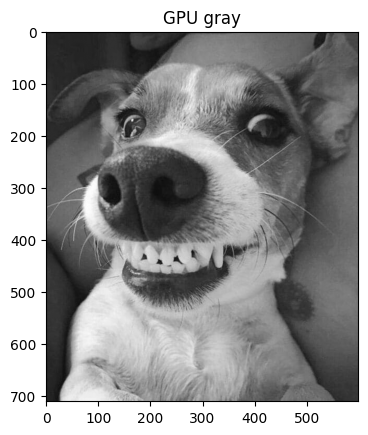

In [68]:
gp_image = gray_gpu.reshape(height, width)
plt.imshow(gp_image, cmap="gray")
plt.title("GPU gray")

Text(0.5, 1.0, 'GPU binarization')

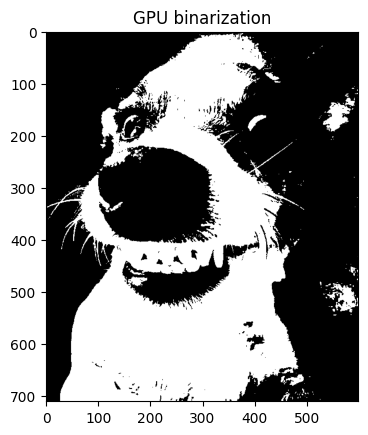

In [69]:
bin_image = binary_gpu.reshape(height, width)
plt.imshow(bin_image, cmap="gray")
plt.title("GPU binarization")

Brightness control

In [70]:
BRIGHTNESS = 60
devBright = cuda.device_array(img.shape, dtype=np.uint8)

In [ ]:
@cuda.jit
def brightness(src, dst, value):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  for c in range(src.shape[2]):
    v = int(src[tidy, tidx, c]) + value
    if v < 0:
      v = 0
    elif v > 255:
      v = 255
    dst[tidy, tidx, c] = v

In [73]:
start = time.time()

brightness[gridSize, blockSize](devSrc, devBright, BRIGHTNESS)

cuda.synchronize()
end = time.time()
time_bright = end - start
print(f"GPU time: {time_bright:.6f} seconds")

GPU time: 0.000929 seconds


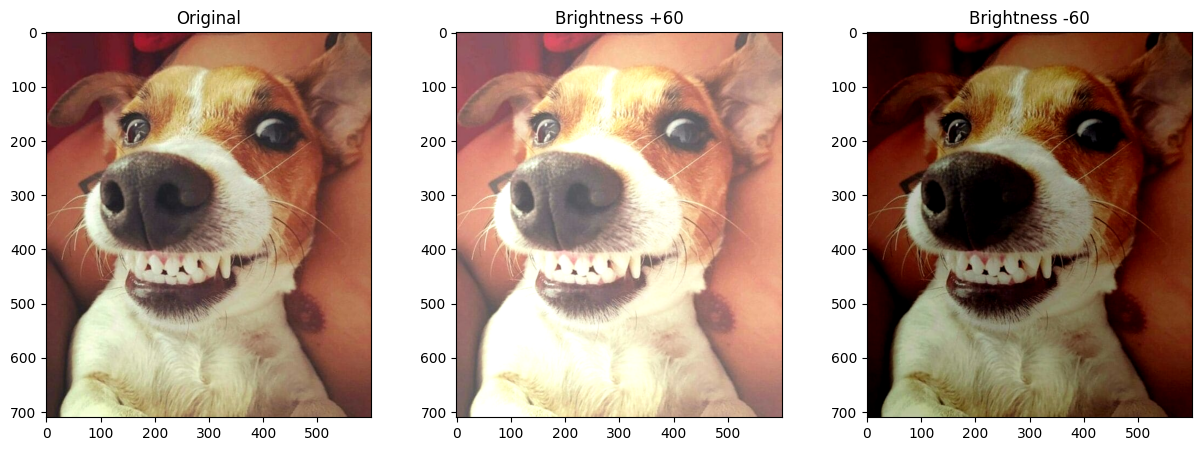

In [74]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original")

i = 2
for value in [BRIGHTNESS, -BRIGHTNESS]:
    brightness[gridSize, blockSize](devSrc, devBright, value)
    cuda.synchronize()
    plt.subplot(1, 3, i)
    plt.imshow(devBright.copy_to_host())
    plt.title(f"Brightness {value:+d}")
    i += 1

plt.show()

Blending images

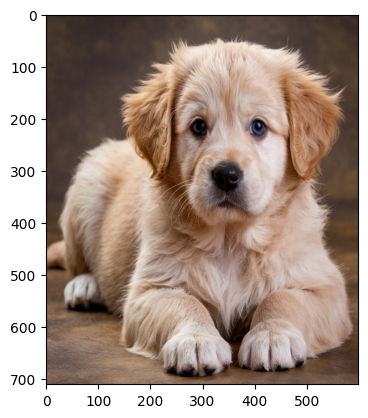

In [84]:
from PIL import Image

IMAGE2= "/content/puppy.jpg"
BLEND_COEF = 0.5

def load_second_image(path, width, height):
  second = Image.open(path).convert("RGB").resize((width, height))
  return np.array(second, dtype=np.uint8)

img2 = load_second_image(IMAGE2, width, height)

plt.imshow(img2)

In [85]:
devSrc2 = cuda.to_device(img2)
devBlend = cuda.device_array(img.shape, dtype=np.uint8)

In [102]:
@cuda.jit
def blend(src1, src2, dst, coef):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  for c in range(src1.shape[2]):
    q = coef * float(src1[tidy, tidx, c]) + (1.0 - coef) * float(src2[tidy, tidx, c])
    dst[tidy, tidx, c] = np.uint8(q)

In [105]:
start = time.time()

blend[gridSize, blockSize](devSrc, devSrc2, devBlend, BLEND_COEF)

cuda.synchronize()
end = time.time()
time_blend = end - start
print(f"GPU time: {time_blend:.6f} seconds")

GPU time: 0.002849 seconds


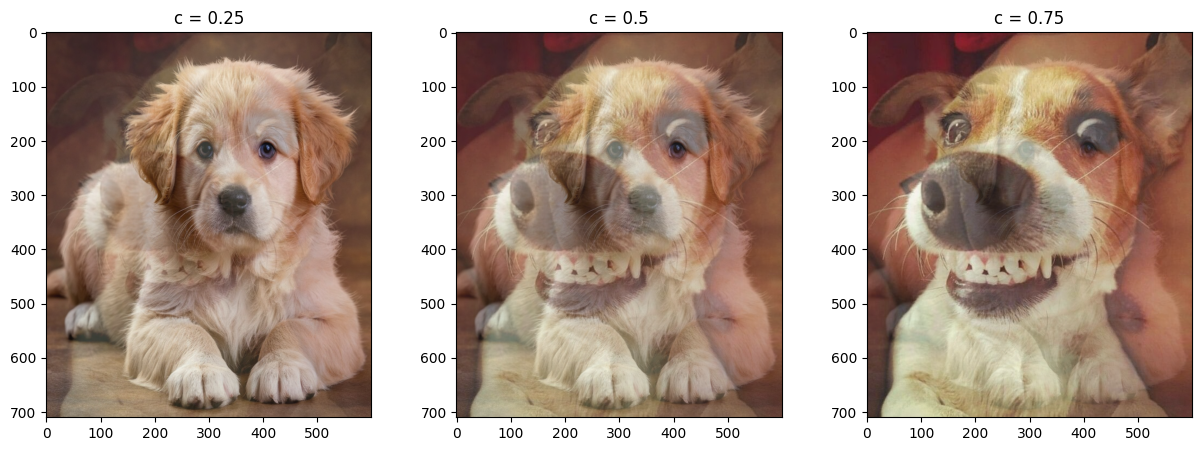

In [117]:
plt.figure(figsize=(15, 5))

i = 1
for coef in [0.25, 0.5, 0.75]:
    blend[gridSize, blockSize](devSrc, devSrc2, devBlend, coef)
    cuda.synchronize()
    plt.subplot(1, 3, i)
    plt.imshow(devBlend.copy_to_host())
    plt.title(f"c = {coef}")
    i += 1
plt.show()


In [108]:
devGray1 = cuda.device_array((height, width, 1), dtype=np.uint8)
devGray2 = cuda.device_array((height, width, 1), dtype=np.uint8)

grayscale[gridSize, blockSize](devSrc, devGray1)
cuda.synchronize()

devImg2 = cuda.to_device(img2)
grayscale[gridSize, blockSize](devImg2, devGray2)
cuda.synchronize()

#blend
devGrayBlend = cuda.device_array((height, width, 1), dtype=np.uint8)
blend[gridSize, blockSize](devGray1, devGray2, devGrayBlend, BLEND_COEF)
cuda.synchronize()

In [109]:
gray_blend = devGrayBlend.copy_to_host()

Text(0.5, 1.0, 'Grayscale blend')

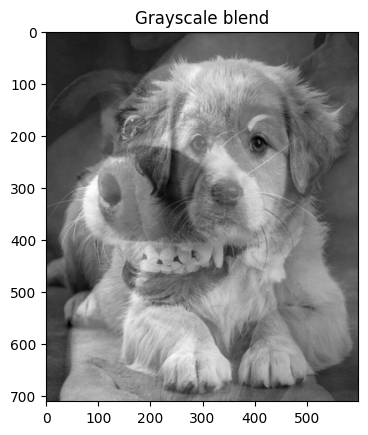

In [110]:
plt.imshow(gray_blend, cmap="gray")
plt.title("Grayscale blend")

Experiment

In [114]:
block_2d = [(8, 4), (16, 4), (8, 16), (16, 16), (32, 16), (32, 32)]
brightness_times = []
blend_times = []
binarize_times = []

for block in block_2d:
    block_x = block[0]
    block_y = block[1]
    blockSize_2D = (block_x, block_y)
    gridSize_2D = (math.ceil(width / block_x), math.ceil(height / block_y))

    #brightness
    start = time.time()
    brightness[gridSize_2D, blockSize_2D](devSrc, devBright, BRIGHTNESS)
    cuda.synchronize()
    end = time.time()
    brightness_times.append(end - start)

    #blend
    start = time.time()
    blend[gridSize_2D, blockSize_2D](devSrc, devSrc2, devBlend, BLEND_COEF)
    cuda.synchronize()
    end = time.time()
    blend_times.append(end - start)

    #binarize
    start = time.time()
    grayscale[gridSize_2D, blockSize_2D](devSrc, devGray)
    binarize[gridSize_2D, blockSize_2D](devGray, devDst, THRESHOLD)
    cuda.synchronize()
    end = time.time()
    binarize_times.append(end - start)


    print(f"Block size: {block_x} x {block_y}")
    print(f"Grid size: {gridSize_2D}")
    print(f"Threads per block: {block_x * block_y}")
    print(f"Brightness: {brightness_times[-1]:.6f} seconds")
    print(f"Blending: {blend_times[-1]:.6f} seconds")
    print(f"Binarization: {binarize_times[-1]:.6f} seconds")
    print()


Block size: 8 x 4
Grid size: (75, 178)
Threads per block: 32
Brightness: 0.000995 seconds
Blending: 0.000353 seconds
Binarization: 0.000299 seconds

Block size: 16 x 4
Grid size: (38, 178)
Threads per block: 64
Brightness: 0.000165 seconds
Blending: 0.000454 seconds
Binarization: 0.000274 seconds

Block size: 8 x 16
Grid size: (75, 45)
Threads per block: 128
Brightness: 0.000170 seconds
Blending: 0.000284 seconds
Binarization: 0.000241 seconds

Block size: 16 x 16
Grid size: (38, 45)
Threads per block: 256
Brightness: 0.000177 seconds
Blending: 0.000304 seconds
Binarization: 0.000210 seconds

Block size: 32 x 16
Grid size: (19, 45)
Threads per block: 512
Brightness: 0.000193 seconds
Blending: 0.000278 seconds
Binarization: 0.000241 seconds

Block size: 32 x 32
Grid size: (19, 23)
Threads per block: 1024
Brightness: 0.000128 seconds
Blending: 0.000283 seconds
Binarization: 0.000230 seconds



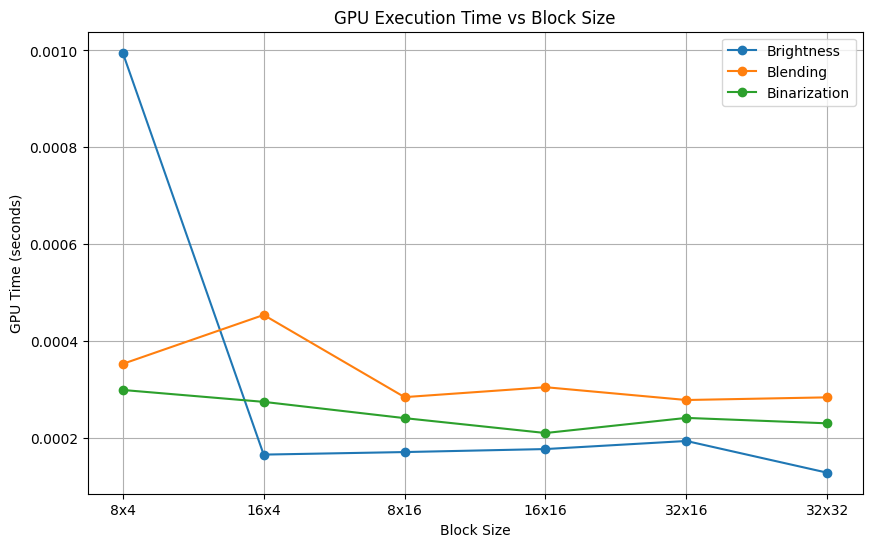

In [115]:
block_labels = [f"{x}x{y}" for x, y in block_2d]

plt.figure(figsize=(10, 6))
plt.plot(block_labels, brightness_times, marker="o", label="Brightness")
plt.plot(block_labels, blend_times, marker="o", label="Blending")
plt.plot(block_labels, binarize_times, marker="o", label="Binarization")
plt.xlabel("Block Size")
plt.ylabel("GPU Time (seconds)")
plt.title("GPU Execution Time vs Block Size")
plt.legend()
plt.grid(True)
plt.show()
